# 3B1B 线性代数：纯几何直觉笔记 (Ep.5–8)

## Ep.5 三维空间中的线性变换
* **核心法则**：与二维完全一致。不管空间怎么扭曲，网格线始终保持平行且等距，原点固定不动。
* **矩阵的几何意义**：一个 $3 \times 3$ 矩阵的纯几何视角，就是追踪三个基向量 $\hat{i}$、$\hat{j}$、$\hat{k}$ 变换后的**新着陆点**（矩阵的每一列）。

## Ep.6 行列式 (Determinant)
* **几何本质**：线性变换对空间**面积（2D）或体积（3D）的缩放比例**。
* **三种状态**：
    * **大于 0**：空间被拉伸或压缩，但空间的方向感（定向）不变。
    * **小于 0**：空间被**翻转**了（如同纸面被翻面，或者 3D 中的右手坐标系变成了左手坐标系）。
    * **等于 0**：**降维打击**。空间被“拍扁”成了低维度的线或点，此时原本的体积/面积彻底归零。

## Ep.7 逆矩阵、列空间与零空间
* **逆矩阵 ($A^{-1}$)**：
    * **直觉**：**“倒放”** 变换过程。如果 $A$ 把空间向右拉伸，$A^{-1}$ 就把它向左压回去。
    * **前提**：只有当空间没有被“拍扁”（$\det \neq 0$）时才能倒放。如果二维平面已经被压成了一条线，你无法把一条线“解压”还原出原本的二维平面。
* **列空间 (Column Space)**：
    * **直觉**：矩阵所有列向量能够“张成”的**所有可达区域**。
    * 它代表了这个线性变换能把原空间映射到的“势力范围”。
* **秩 (Rank)**：
    * **直觉**：列空间的**真实几何维度**。满秩代表维度没变，秩为 1 代表空间坍塌成了一条线。
* **零空间 (Null Space)**：
    * **直觉**：空间发生降维坍塌时，那些**被无情压缩到原点 (0,0)** 的所有向量集合。

## Ep.8 非方阵 (Nonsquare Matrices)
* **几何本质**：**不同维度空间**之间的转换门。
* **列数**：代表出发空间（输入）的维度。
* **行数**：代表目标空间（输出）的维度。
* **具体画面**：
    * **$3 \times 2$ 矩阵**：把一个 2D 平面，硬生生地放置到一个 3D 空间中（它的列空间是 3D 里的一个切面）。
    * **$2 \times 3$ 矩阵**：用一束光，把一个 3D 空间里的物体，“拍扁”投射到一个 2D 墙面上。

# Day 3 机器学习补充笔记：回归与梯度下降细节 (李宏毅 Regression)

## 1. 误差曲面 (Error Surface)
* **概念**：将未知参数（$w$ 和 $b$）的所有可能组合，与它们对应的 Loss 值画在图上，形成的一个三维地形图（通常用二维等高线图展示）。
* **几何直觉**：
  * 每一组 $(w, b)$ 就是地图上的一个坐标点。
  * Loss 值就是该点的“海拔高度”。颜色越深（或偏蓝）代表海拔越低，误差越小。
  * **目标**：从地图上的随机出生点出发，一路走到“海拔最低的谷底”。

## 2. 梯度下降 (Gradient Descent) 底层机制
* **参数更新公式**：$w \leftarrow w - \eta \frac{\partial L}{\partial w}$ （偏置 $b$ 的更新同理）
* **动作拆解**：
  * **算斜率（求导 $\frac{\partial L}{\partial w}$）**：指明方向。
    * 若斜率为**正**（左低右高）：说明继续往右走 Loss 会增加。我们要**往左走**（$w$ 减小）。
    * 若斜率为**负**（左高右低）：说明继续往右走 Loss 会减少。我们要**往右走**（$w$ 增大）。
    * *设计之美*：公式里自带的**负号**，完美保证了不管原来在左边还是右边，更新方向永远指着“下坡”。
  * **学习率（$\eta$, Learning Rate）**：控制步长。
    * **太小**：像蜗牛下山，虽然稳但训练极其耗时。
    * **太大**：步子跨太大，容易直接越过谷底跑到对面山坡，甚至越跳越高（Loss 爆炸、模型发散）。
  * **自动减速机制**：越接近谷底，地形越平缓（斜率变小），公式计算出来的移动距离也会自动变短，从而平稳滑入最低点。

## 3. 参数 (Parameter) vs 超参数 (Hyperparameter)
* **参数 (Parameter)**：比如 $w$ 和 $b$。这是机器通过算梯度自己**学**出来、**找**出来的。
* **超参数 (Hyperparameter)**：比如学习率 $\eta$、训练的轮数（Epoch）。这是必须由**人类程序员手动设定**的规则。俗称“炼丹”调的就是这些数值。

## 4. 线性回归的“主角光环”
* 在今天的线性回归任务中，MSE（均方误差）构成的 Loss 地形图永远是一个完美的“大锅底”（凸函数 Convex）。
* 这意味着**它只有一个谷底**。不管你怎么随机初始化参数，只要学习率合适，梯度下降**必定**能带你找到全局最优解（Global Minimum），不用担心卡在半山腰。

In [1]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

# Day 3 d2l 实操核心笔记：3.2.1 生成合成数据

## 1. 核心目的
自己扮演“上帝”，设定好真实的权重 $w$ 和偏置 $b$（即**标准答案**），并以此生成一批带有随机噪音的数据。主要用于在初期阶段，检验我们手写的模型能否精准地把这个“标准答案”反推（学）出来。

## 2. 核心数学公式
$$y = Xw + b + \epsilon$$

* **$Xw + b$**：绝对完美的线性规律。
* **$\epsilon$ (噪音)**：模拟现实世界中不可避免的测量误差。加入噪音能让数据看起来更真实（散布在直线周围），迫使模型去学习“穿透噪音找规律”。

---

## 3. 代码实现骨架
以下代码是上述数学公式在 PyTorch 中的完美翻译：

In [ ]:
""" 1.生成数据 """
def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声"""
    # 第一步：捏造特征矩阵 X 
    # 从均值为0、方差为1的正态分布中提取随机数。
    # 矩阵形状为 (样本数量, 特征数量)
    X = torch.normal(0, 1, (num_examples, len(w)))
    
    # 第二步：计算完美的预测值 y
    # 使用张量乘法，标量 b 会触发自动广播机制 (Broadcast)
    y = torch.matmul(X, w) + b
    
    # 第三步：注入灵魂 (加入噪音)
    # 给 y 加上均值为0，方差为0.01的微小正态分布扰动
    y += torch.normal(0, 0.01, y.shape)
    
    # 将 y 强行重塑为一列 (列向量)，防止后续维度错位报错
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

print('features:', features[0], '\nlabels:', labels[0])

features: tensor([ 0.6112, -0.8836]) 
labels: tensor([8.4122])


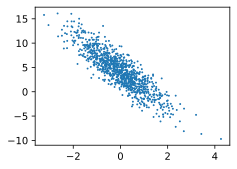

In [ ]:
d2l.set_figsize()
# 带梯度的张量不能直接画图，必须先 .detach() 扒掉计算图，再 .numpy() 转换格式
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

**必记 PyTorch API**

torch.normal(mean, std, size)：生成正态（高斯）分布的随机数张量。深度学习中最常用的“无中生有”造数据、或者初始化参数的工具。

torch.matmul(A, B)：张量/矩阵乘法。这是“矢量化加速”的核心，一行代码干掉极其耗时的 for 循环。

tensor.reshape((-1, 1))：

-1 代表“让 PyTorch 自动推导该维度的长度”。

1 代表“强制固定为 1 列”。

在处理标签数据（Label）时极其常用，能有效避免广播机制引发的诡异 Bug。

In [7]:
""" 2.给模型造一台自动喂饭机--数据迭代器 """
def data_iter(batch_size, features, labels):
    num_examples = len(features)

    # 动作 1：生成索引并打乱 (极其重要！)
    # 生成一张从 0 到 999 的“座位表”
    indices = list(range(num_examples))
    # 把座位表彻底打乱，防止模型“死记硬背”数据的固定顺序
    random.shuffle(indices)

    # 动作 2：切块
    # 比如 batch_size 是 10，就每隔 10 步切一刀
    for i in range(0, num_examples, batch_size):
        # 拿出这一刀切出来的 10 个随机座号
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        
        # 动作 3：端菜 (yield)
        # 根据座号，去 features 和 labels 里把对应的数据抽出来，端给模型
        yield features[batch_indices], labels[batch_indices]

In [13]:
# 直观感受一下
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.1782,  0.4513],
        [ 1.6097,  0.0444],
        [-1.7844, -0.0408],
        [ 3.4079, -0.7371],
        [-1.8840,  0.5036],
        [-0.1795, -0.5977],
        [-1.2440, -0.9802],
        [ 1.2147,  0.2418],
        [ 0.5869,  0.2788],
        [-0.2299, -0.3090]]) 
 tensor([[ 3.0283],
        [ 7.2755],
        [ 0.7736],
        [13.5292],
        [-1.2756],
        [ 5.8667],
        [ 5.0448],
        [ 5.8073],
        [ 4.4395],
        [ 4.7900]])


In [14]:
""" 随机初始化模型参数 """
# 成形状为 (2, 1) 的随机权重矩阵，因为我们有 2 个特征
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
# 偏置就是一个纯数字，初始设为 0
b = torch.zeros(1, requires_grad=True)

In [15]:
""" 定义模型 """
def linreg(X, w, b):
    """ 线性回归模型 """
    return torch.matmul(X, w) + b

""" 定义Loss """
def squared_loss(y_hat, y):
    """ 均方损失 """
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [16]:
""" 定义优化算法 """
def sgd(params, lr, batch_size):
    """ 小批量随机梯度下降 """
    # 暂时停止监控梯度
    with torch.no_grad():
        for param in params:
            # 新位置 = 老位置 - 学习率 * 梯度
            # 为什么要除以 batch_size？ 因为你刚才算 Loss 的时候，是一整批数据（比如 10 个）的误差加在一起的总和。
            # 为了不让步子迈得太大，这里要除以 10，算出这一批数据的平均梯度。
            param -= lr * param.grad / batch_size
            param.grad.zero_() # 梯度清零

In [21]:
lr = 0.05 # 学习率
num_epochs = 3 # 总共复习 3 遍数据集
net = linreg # 你写的模型函数
loss = squared_loss # 你写的损失函数

for epoch in range(num_epochs):
    # --- 内层循环：按批次抓取数据 ---
    for X, y in data_iter(batch_size, features, labels):
        
        # 第 1 & 2 步：算预测值，并算这一批数据的 Loss
        l = loss(net(X, w, b), y) 
        
        # 第 3 步：反向传播算梯度
        # 因为 l 是一个向量（这一批里每个样本都有一个 loss）
        # 所以要先 .sum() 加起来变成一个标量，再求导
        l.sum().backward() 
        
        # 第 4 步：更新参数并清空梯度
        sgd([w, b], lr, batch_size) 
        
    # --- 每一轮 (Epoch) 结束后的汇报 ---
    with torch.no_grad(): # 汇报时不需要算梯度
        # 用更新后的 w 和 b，去算一下整个数据集的误差，看看降没降
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')
        # 打印真实值与学到的值的误差
        print(f'w 的估计误差: {true_w - w.reshape(true_w.shape)}')
        print(f'b 的估计误差: {true_b - b}')

epoch 1, loss 0.000051
w 的估计误差: tensor([0.0008, 0.0002])
b 的估计误差: tensor([-0.0001])
epoch 2, loss 0.000051
w 的估计误差: tensor([0.0007, 0.0006])
b 的估计误差: tensor([0.0005])
epoch 3, loss 0.000051
w 的估计误差: tensor([ 0.0007, -0.0004])
b 的估计误差: tensor([2.6703e-05])


### 核心笔记：线性回归的“矩阵维度消消乐”

在深度学习的前向传播公式 $\hat{y} = Xw + b$ 中，必须严格遵守**矩阵乘法的维度消除法则**：中间的维度必须绝对相等，相乘后互相抵消，最终结果继承首尾的维度。

#### 1. 黄金定式（直接套用模板）
无论你的数据量有多庞大，形状永远遵循以下规则：
* **特征矩阵 $X$**：`(batch_size, num_features)` ➡️ `(样本数, 特征数)`
* **权重向量 $w$**：`(num_features, 1)` ➡️ `(特征数, 1列)`
* **预测结果 $\hat{y}$**：`(batch_size, 1)` ➡️ `(样本数, 1列)`

#### 2. 实战推导（第三题复盘）
已知设定：`batch_size = 16`，特征数 = `3`。

矩阵乘法推导过程如下：
$$X \cdot w = \hat{y}$$
$$(16 \times 3) \cdot (3 \times 1) \longrightarrow (16 \times 1)$$

**推导三步曲**：
1. **对齐**：$X$ 的列数（3）必须等于 $w$ 的行数（3），否则 PyTorch 会直接抛出维度报错！
2. **消除**：矩阵相乘时，内部相邻的 `3` 碰在一起“消掉”。
3. **成型**：剩下外侧的 `16` 和 `1`，组合成最终预测值 $\hat{y}$ 的形状 `(16, 1)`。

> **终极避坑指南**：
> 在写代码定义权重 $w$ 或标签 $y$ 时，千万不要让它们变成一维的列表（例如 `torch.Size([16])`）。必须使用 `.reshape((-1, 1))` 强行把它们变成二维的列向量 `(16, 1)`。如果不这么做，PyTorch 可能会触发极其诡异的**自动广播机制 (Broadcasting)**，导致你的 Loss 算出一个巨大的错误矩阵！